# 18 - How Robust Is the Crisis to Coverage? (Manski bounds, 2022)

Every rate in this project is computed among the students PISA *sampled* - but PISA 2022 covered only about **79%** of Albania's 15-year-olds (Coverage Index 3 ~ 0.79; 6 129 students representing ~28 400 of ~36 000, OECD Country Note). The ~21% uncovered - disproportionately out-of-school, disadvantaged youth - are unobserved. Rather than assume they resemble the sample, this notebook reports the **range of population at-risk rates consistent with the data** (Manski partial identification, `src/coverage/manski.py`, `scripts/run_coverage_bounds.py`).

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
import json
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
S = json.load(open('../outputs/results/coverage_bounds_2022.json'))
sens = pd.read_csv('../outputs/results/coverage_sensitivity_2022.csv')
S

{'cycle': 2022,
 'coverage_index3': 0.79,
 'observed_at_risk_covered': 0.7394,
 'observed_se_design_based': 0.0041,
 'observed_ci95': [0.7314, 0.7474],
 'poorest_quintile_rate': 0.8547,
 'richest_quintile_rate': 0.5783,
 'worst_case_bounds': {'lower': 0.5842,
  'upper': 0.7942,
  'width': 0.21,
  'assumption': 'worst-case (u in [0,1])'},
 'monotone_bounds_uncovered_worse': {'lower': 0.7394,
  'upper': 0.7942,
  'width': 0.0547,
  'assumption': 'monotone: uncovered >= covered (u >= p)'},
 'scenarios': {'uncovered_like_poorest_quintile': 0.7636,
  'uncovered_like_overall_sample': 0.7394,
  'uncovered_like_richest_quintile': 0.7056}}

## 1. The bounds

With coverage $c$, observed covered rate $p$, and unknown uncovered rate $u\in[0,1]$, the population rate is $P=cp+(1-c)u$. Worst-case takes $u\in[0,1]$; the monotone bound uses $u\ge p$ (out-of-school youth are, if anything, more at risk).

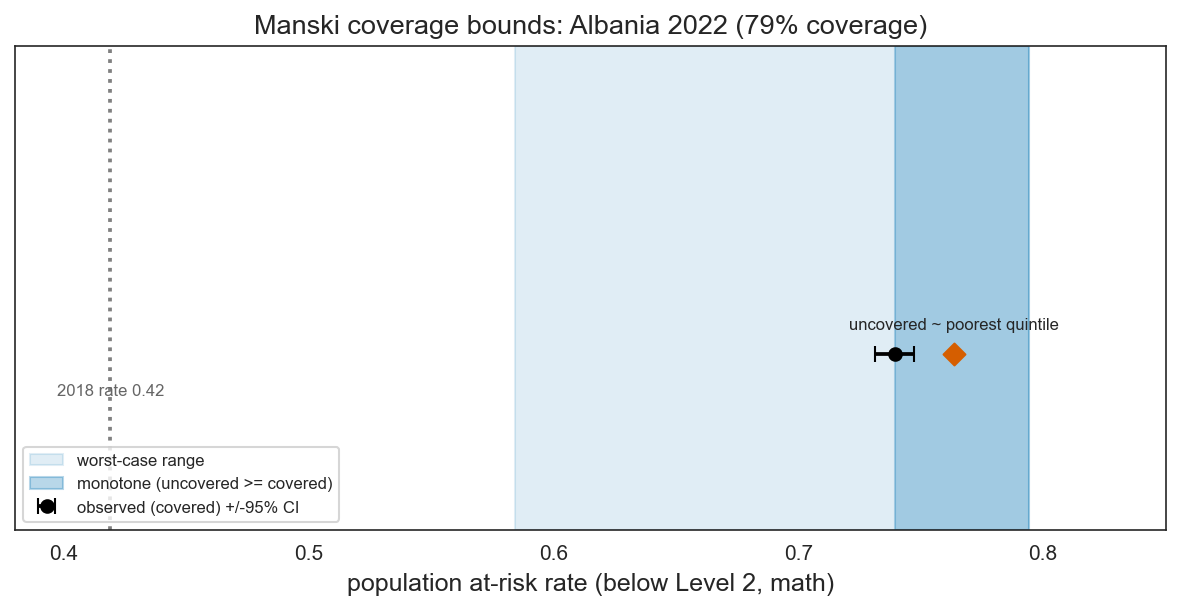

In [3]:
p=S['observed_at_risk_covered']; se=S['observed_se_design_based']
wc=S['worst_case_bounds']; mono=S['monotone_bounds_uncovered_worse']; sc=S['scenarios']
fig, ax = plt.subplots(figsize=(8,4.2))
ax.axvspan(wc['lower'], wc['upper'], color=PALETTE['blue'], alpha=0.12, label='worst-case range')
ax.axvspan(mono['lower'], mono['upper'], color=PALETTE['blue'], alpha=0.28, label='monotone (uncovered >= covered)')
ax.errorbar([p],[1.0], xerr=[[1.96*se],[1.96*se]], fmt='o', color=PALETTE['black'], capsize=4, label='observed (covered) +/-95% CI')
ax.scatter([sc['uncovered_like_poorest_quintile']],[1.0], marker='D', s=55, color=PALETTE['vermilion'], zorder=5)
ax.annotate('uncovered ~ poorest quintile', (sc['uncovered_like_poorest_quintile'],1.0), xytext=(0,12), textcoords='offset points', ha='center', fontsize=8)
ax.axvline(0.419, ls=':', color='0.5'); ax.annotate('2018 rate 0.42', (0.419,1.0), xytext=(0,-20), textcoords='offset points', ha='center', fontsize=8, color='0.4')
ax.set_yticks([]); ax.set_ylim(0.8,1.35); ax.set_xlim(0.38,0.85)
ax.set_xlabel('population at-risk rate (below Level 2, math)')
ax.set_title('Manski coverage bounds: Albania 2022 (79% coverage)')
ax.legend(loc='lower left', fontsize=8); plt.tight_layout(); plt.show()

**Reading:** the observed covered rate is **0.74** (design-based SE 0.004 - sampling noise is tiny next to the coverage gap). Without any assumption the population rate is only pinned to **[0.58, 0.79]**. But the credible direction is one-sided: out-of-school 15-year-olds are not *less* at risk than enrolled ones, so under the **monotone** assumption the rate is **[0.74, 0.79]** - coverage, if anything, means the headline *understates* the crisis. Anchoring the uncovered to the poorest covered quintile (reweighting) puts it at **~0.76**.

## 2. The crisis conclusion survives any coverage assumption

The important robustness check: is 'Albania deteriorated sharply from 2018' an artefact of who got sampled?

Worst-case LOWER bound on 2022 rate: 0.584
Albania 2018 at-risk rate         : 0.419
Gap even in the most optimistic case: +0.165


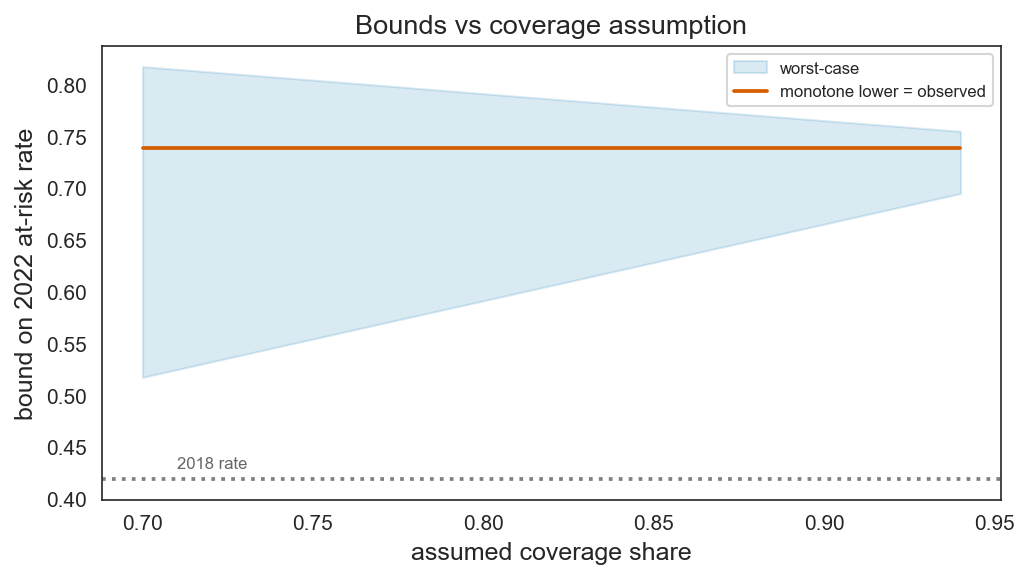

In [4]:
print(f"Worst-case LOWER bound on 2022 rate: {wc['lower']:.3f}")
print(f"Albania 2018 at-risk rate         : 0.419")
print(f"Gap even in the most optimistic case: {wc['lower']-0.419:+.3f}")
fig, ax = plt.subplots(figsize=(7,4))
ax.fill_between(sens.coverage, sens.wc_lower, sens.wc_upper, alpha=0.15, color=PALETTE['blue'], label='worst-case')
ax.plot(sens.coverage, sens.mono_lower, color=PALETTE['vermilion'], label='monotone lower = observed')
ax.axhline(0.419, ls=':', color='0.5'); ax.text(0.71,0.43,'2018 rate', fontsize=8, color='0.4')
ax.set_xlabel('assumed coverage share'); ax.set_ylabel('bound on 2022 at-risk rate')
ax.set_title('Bounds vs coverage assumption'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading:** even the **worst-case lower bound (0.58)** sits ~16 pp above Albania's 2018 rate of 0.42, and stays above it across every plausible coverage share. No coverage assumption - however adversarial - can explain away the 2018->2022 deterioration. The *level* is uncertain by ~21 pp in the worst case; the *conclusion* is not.

## Conclusions & Interpretation

- **The reported rate is a covered-population rate.** At 79% coverage the sampling SE (0.004) badly understates total uncertainty; the coverage gap is the real one.
- **Partial identification, honestly stated:** worst-case [0.58, 0.79]; under the credible monotone assumption [0.74, 0.79], i.e. the headline likely *understates* the crisis rather than overstating it.
- **The comparative claim is robust.** The 2022 rate exceeds the 2018 rate under every coverage assumption, so the deterioration is not a sampling artefact - it is the one conclusion coverage cannot touch.
- **Method, not hand-wringing:** bounds + a reweighting scenario turn a data-quality caveat into a quantified robustness result, the honest complement to the point estimates elsewhere in the project.